(512, 1024, 3) 0.0037174225 17152.0 0.27061555 <class 'numpy.ndarray'> float32
0.27061555 17152.0 0.0037174225 0.27061555
0.2706144797808548 17149.329131269693 0.003855096181287402 0.2706144797808548


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


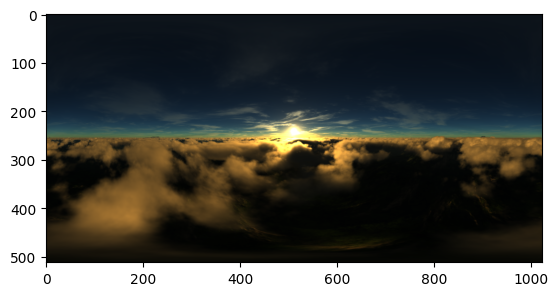

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


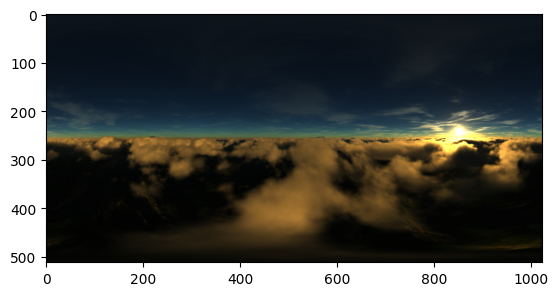

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(512, 1024, 3) 0.003855096181287402 17149.329131269693 0.2706144797808548 <class 'numpy.ndarray'> float64
(512, 1024, 3) 0.0038547516 17152.0 0.27060854 <class 'numpy.ndarray'> float32


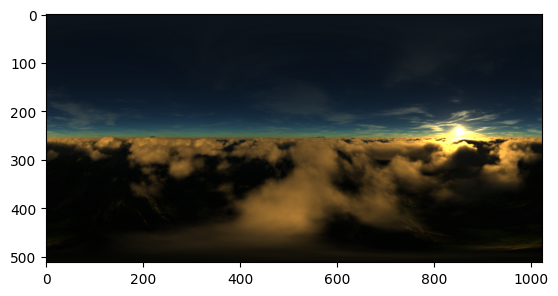

In [ ]:
import numpy as np
from envmap import EnvironmentMap, rotation_matrix
import skimage.io
import matplotlib.pyplot as plt
import os
from imageio import imwrite


def rot_hdr(hdr_image, i, axis='azimuth'):
    rot_deg = i*np.pi/180
    dcm = rotation_matrix(azimuth=rot_deg if axis == 'azimuth' else 0,
                        elevation=rot_deg if axis == 'elevation' else 0,
                        roll=rot_deg if axis == 'roll' else 0)
    e = EnvironmentMap(hdr_image, 'latlong')
    e_rot = e.copy().rotate(dcm)
    hdr_image_rot = e_rot.data    # np.array of shape [H, W, 3], min: 0, max: 1
    print(np.mean(hdr_image), np.max(hdr_image), np.min(hdr_image), np.mean(hdr_image))
    print(np.mean(hdr_image_rot), np.max(hdr_image_rot), np.min(hdr_image_rot), np.mean(hdr_image_rot))
    return hdr_image_rot
    
path = f"/home/mint/Dev/DiFaReli/TPAMI_baseline_MajorRevision/Neural_Gaffer/demo/environment_map_sample/"
# env_name = "125_hdrmaps_com_free_2K.exr"
env_name = "117_hdrmaps_com_free_2K.exr"
hdr_image = skimage.io.imread(path + env_name)
hdr_image = skimage.img_as_float(hdr_image)
print(hdr_image.shape, np.min(hdr_image), np.max(hdr_image), np.mean(hdr_image), type(hdr_image), hdr_image.dtype)
hdr_image_rot = rot_hdr(hdr_image, 120, axis='azimuth')
plt.imshow(hdr_image)
plt.show()
plt.imshow(hdr_image_rot)
plt.show()

out_path = f"/home/mint/Dev/DiFaReli/TPAMI_baseline_MajorRevision/Neural_Gaffer/demo/rotate_environment_map_sample/"
os.makedirs(out_path, exist_ok=True)
# Save the rotated HDR image
print(hdr_image_rot.shape, np.min(hdr_image_rot), np.max(hdr_image_rot), np.mean(hdr_image_rot), type(hdr_image_rot), hdr_image_rot.dtype)
imwrite(os.path.join(out_path, f"rotated_{env_name}.exr"), hdr_image_rot.astype(np.float32), format="EXR")

reload_rotate_hdr_image = skimage.io.imread(os.path.join(out_path, f"rotated_{env_name}"))
reload_rotate_hdr_image = skimage.img_as_float(reload_rotate_hdr_image)
print(reload_rotate_hdr_image.shape, np.min(reload_rotate_hdr_image), np.max(reload_rotate_hdr_image), np.mean(reload_rotate_hdr_image), type(reload_rotate_hdr_image), reload_rotate_hdr_image.dtype)
plt.imshow(reload_rotate_hdr_image)
plt.show()

